# Module 1: Mathematical Foundations of Neural Networks

**Audience:** Total beginners — no prior machine learning required.

**What you will learn:**
- What a neuron and perceptron are
- How weighted sums and bias work
- Common activation functions (Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax)
- Forward propagation in one neuron
- How to implement a single neuron with **NumPy**

**How to use this notebook:**
1. Run cells from top to bottom (`Shift + Enter`).
2. Read every markdown cell carefully — the math is explained in plain language.
3. Change numbers in code cells and re-run to build intuition.

---
## Setup: Import libraries

We use **NumPy** for numerical computation (arrays, dot products) and **Matplotlib** to plot activation functions so you can *see* what they do.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice in Jupyter
%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")  # fallback if seaborn style unavailable

print("NumPy version:", np.__version__)

NumPy version: 1.26.4


---
# Part 1: Neurons and Perceptrons

## 1.1 Biological neuron (intuition only)

In the brain, a **neuron** receives signals from other neurons through **connections**. If enough signal builds up, the neuron **fires** and sends output to the next neurons.

We do **not** simulate biology in code. We borrow one idea:

> **Combine many inputs → decide whether / how strongly to pass a signal onward.**

## 1.2 Artificial neuron (the building block of neural networks)

An **artificial neuron** is a small mathematical function:

1. Take several **inputs** \(x_1, x_2, \ldots, x_n\) (numbers).
2. Multiply each input by a **weight** \(w_1, w_2, \ldots, w_n\) (learnable importance).
3. Add a **bias** \(b\) (extra knob to shift the decision).
4. Apply an **activation function** \(f\) to produce the **output**.

In one line:

$$\text{output} = f\bigl(w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b\bigr)$$

Think of weights as "how much I listen to each input," bias as "how easy it is to fire," and activation as "what I send out."

## 1.3 Perceptron (historical name)

A **perceptron** (Frank Rosenblatt, 1958) is one of the earliest artificial neurons. Originally it often used a **step** activation: output 1 if the weighted sum is above a threshold, else 0.

Today people say "perceptron" to mean a **single neuron** — especially a linear score plus a simple activation. Modern networks stack many such neurons in **layers**.

| Term | Meaning |
|------|--------|
| Input | Features you feed in (e.g. pixel brightness, exam scores) |
| Weight | Strength of each input connection |
| Bias | Constant added before activation |
| Activation | Nonlinear function that shapes the output |
| Output | Number the neuron sends to the next layer |

---
# Part 2: Weighted Sum Calculation

## 2.1 What is a weighted sum?

Suppose you have 3 inputs and 3 weights:

| Input \(x\) | Weight \(w\) | Product \(w \times x\) |
|-------------|--------------|-------------------------|
| \(x_1 = 2\) | \(w_1 = 0.5\) | \(0.5 \times 2 = 1.0\) |
| \(x_2 = 1\) | \(w_2 = -1.0\) | \(-1.0 \times 1 = -1.0\) |
| \(x_3 = 3\) | \(w_3 = 2.0\) | \(2.0 \times 3 = 6.0\) |

**Weighted sum** (before bias):

$$z = w_1 x_1 + w_2 x_2 + w_3 x_3 = 1.0 + (-1.0) + 6.0 = 6.0$$

- A **positive weight** means "increase the score when this input grows."
- A **negative weight** means "decrease the score when this input grows."
- A **large magnitude** means "this input matters a lot."

## 2.2 Dot product (the fast way)

If **x** and **w** are vectors (lists of numbers), the weighted sum is the **dot product**:

$$z = \mathbf{w} \cdot \mathbf{x} = \sum_{i=1}^{n} w_i x_i$$

In NumPy: `np.dot(w, x)` or `w @ x` (same thing for 1D arrays).

This quantity \(z\) is often called the **pre-activation** or **logit** (especially before softmax in classification).

In [2]:
# --- Weighted sum: step by step ---

x = np.array([2.0, 1.0, 3.0])   # inputs
w = np.array([0.5, -1.0, 2.0])  # weights

print("Inputs x:", x)
print("Weights w:", w)
print()

# Manual loop (good for learning)
manual_sum = 0.0
for i in range(len(x)):
    product = w[i] * x[i]
    print(f"  w[{i}]*x[{i}] = {w[i]} * {x[i]} = {product}")
    manual_sum += product

print("\nManual weighted sum z =", manual_sum)

# NumPy dot product (what we use in practice)
z_dot = np.dot(w, x)
z_at = w @ x
print("np.dot(w, x) =", z_dot)
print("w @ x        =", z_at)

Inputs x: [2. 1. 3.]
Weights w: [ 0.5 -1.   2. ]

  w[0]*x[0] = 0.5 * 2.0 = 1.0
  w[1]*x[1] = -1.0 * 1.0 = -1.0
  w[2]*x[2] = 2.0 * 3.0 = 6.0

Manual weighted sum z = 6.0
np.dot(w, x) = 6.0
w @ x        = 6.0


---
# Part 3: Bias Term

## 3.1 Why do we need bias?

Without bias, the weighted sum \(z = \mathbf{w} \cdot \mathbf{x}\) is always **zero** when all inputs are zero — no matter what the weights are.

The **bias** \(b\) is one extra number added **after** the weighted sum:

$$z = \mathbf{w} \cdot \mathbf{x} + b$$

**Intuition:**
- Weights control **slope** — how sensitive the neuron is to each input.
- Bias controls **offset** — it shifts the decision boundary up or down.

Example: predicting "pass exam" from hours studied.
- Weight on hours: "more hours → higher score."
- Bias: "even with 0 hours, baseline chance isn't exactly zero" (or the opposite, depending on training).

## 3.2 Trick: bias as a weight on constant input 1

Some textbooks augment the input vector with a **1** and give the bias its own weight. That unifies "weights + bias" into one dot product. We will use explicit `b` in this notebook because it is clearer for beginners.

In [3]:
# --- Effect of bias on pre-activation z ---

x = np.array([2.0, 1.0, 3.0])
w = np.array([0.5, -1.0, 2.0])

z_no_bias = np.dot(w, x)
b = -2.0
z_with_bias = z_no_bias + b

print("Weighted sum only:", z_no_bias)
print("Bias b:", b)
print("z = w·x + b:", z_with_bias)

# Try changing b in your head: larger b shifts z up; smaller b shifts z down.

Weighted sum only: 6.0
Bias b: -2.0
z = w·x + b: 4.0


---
# Part 4: Activation Functions

## 4.1 Why activation?

If we only used \( \text{output} = z \) (linear), stacking many neurons would still be **one big linear function**. Real patterns (images, language) are **nonlinear**.

An **activation function** \(f\) introduces nonlinearity:

$$a = f(z)$$

We will study five common functions:

| Name | Typical use |
|------|-------------|
| Sigmoid | Binary outputs, old hidden layers |
| Tanh | Hidden layers (zero-centered) |
| ReLU | Default hidden layer in modern CNNs/MLPs |
| Leaky ReLU | ReLU fix when neurons "die" |
| Softmax | Multi-class probabilities (output layer) |

## 4.2 Sigmoid

**Formula:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Range:** \((0, 1)\) — squashes any real number into a probability-like value.

**Pros:** Smooth, differentiable, interpretable as probability.

**Cons:** **Vanishing gradients** for very large \(|z|\) (saturation); outputs not zero-centered.

**When:** Output neuron for **binary classification** (with cross-entropy loss); historically in RNNs.

sigmoid( -5) = 0.0067
sigmoid(  0) = 0.5000
sigmoid(  5) = 0.9933


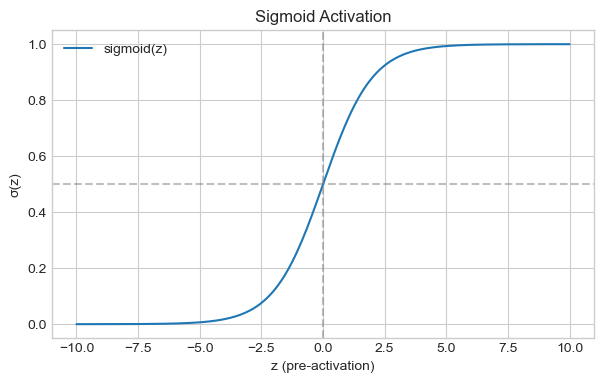

In [4]:
def sigmoid(z):
    """Sigmoid activation. Works on scalars or NumPy arrays."""
    return 1.0 / (1.0 + np.exp(-z))

# Examples
for z in [-5, 0, 5]:
    print(f"sigmoid({z:3}) = {sigmoid(z):.4f}")

# Plot
z_line = np.linspace(-10, 10, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_line, sigmoid(z_line), label="sigmoid(z)", color="C0")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z (pre-activation)")
plt.ylabel("σ(z)")
plt.title("Sigmoid Activation")
plt.legend()
plt.show()

## 4.3 Tanh (Hyperbolic Tangent)

**Formula:**

$$\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$$

Equivalently: \( \tanh(z) = 2\sigma(2z) - 1 \).

**Range:** \((-1, 1)\) — **zero-centered** (unlike sigmoid).

**Pros:** Often trains faster than sigmoid in hidden layers because mean activation near 0.

**Cons:** Still saturates at extremes → vanishing gradients.

**When:** Hidden layers in older architectures; some RNN cells.

tanh(-2) = -0.9640
tanh(0) = 0.0000
tanh(2) = 0.9640


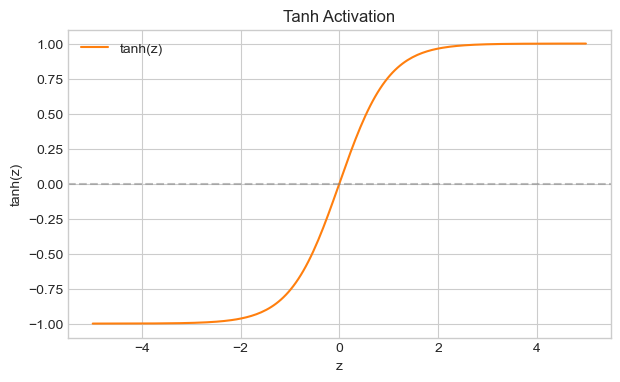

In [5]:
def tanh_activation(z):
    return np.tanh(z)  # NumPy built-in

for z in [-2, 0, 2]:
    print(f"tanh({z}) = {tanh_activation(z):.4f}")

z_line = np.linspace(-5, 5, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_line, tanh_activation(z_line), label="tanh(z)", color="C1")
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z")
plt.ylabel("tanh(z)")
plt.title("Tanh Activation")
plt.legend()
plt.show()

## 4.4 ReLU (Rectified Linear Unit)

**Formula:**

$$\text{ReLU}(z) = \max(0, z) = \begin{cases} z & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Range:** \([0, \infty)\)

**Pros:**
- Very cheap to compute.
- For \(z > 0\), gradient is 1 → helps deep networks train.
- Sparse activations (many zeros).

**Cons:** **Dying ReLU** — if \(z \leq 0\) always, neuron outputs 0 forever and gets zero gradient.

**When:** Default choice for hidden layers in most modern feedforward nets and CNNs.

relu(-3) = 0
relu(0) = 0
relu(3) = 3


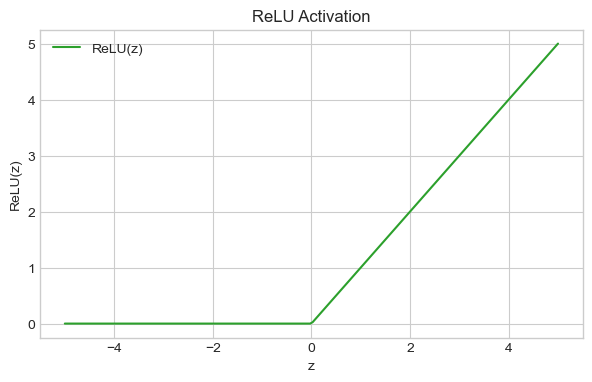

In [6]:
def relu(z):
    return np.maximum(0, z)

for z in [-3, 0, 3]:
    print(f"relu({z}) = {relu(z)}")

z_line = np.linspace(-5, 5, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_line, relu(z_line), label="ReLU(z)", color="C2")
plt.xlabel("z")
plt.ylabel("ReLU(z)")
plt.title("ReLU Activation")
plt.legend()
plt.show()

## 4.5 Leaky ReLU

**Formula** (with small slope \(\alpha\), often 0.01):

$$\text{LeakyReLU}(z) = \begin{cases} z & z > 0 \\ \alpha z & z \leq 0 \end{cases}$$

**Idea:** When \(z\) is negative, allow a **small** negative output instead of hard zero — so the neuron can still get a non-zero gradient and "recover."

**When:** Used when many ReLU neurons die during training.

leaky_relu(-3, alpha=0.01) = -0.0300
leaky_relu(0, alpha=0.01) = 0.0000
leaky_relu(3, alpha=0.01) = 3.0000


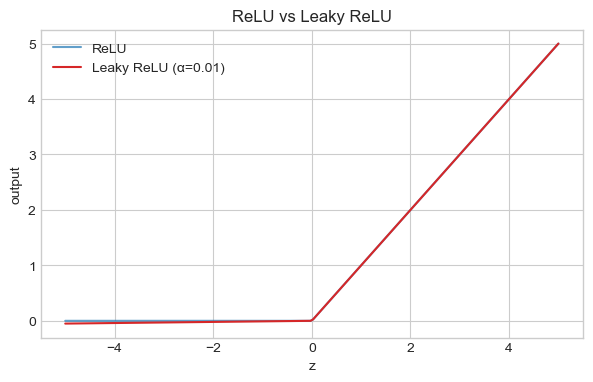

In [7]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

for z in [-3, 0, 3]:
    print(f"leaky_relu({z}, alpha=0.01) = {leaky_relu(z):.4f}")

z_line = np.linspace(-5, 5, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_line, relu(z_line), label="ReLU", alpha=0.7)
plt.plot(z_line, leaky_relu(z_line), label="Leaky ReLU (α=0.01)", color="C3")
plt.xlabel("z")
plt.ylabel("output")
plt.title("ReLU vs Leaky ReLU")
plt.legend()
plt.show()

## 4.6 Softmax

Softmax turns a **vector** of \(K\) scores into **probabilities** that sum to 1. Used at the **output** for multi-class classification (e.g. digit 0–9).

For logits \(z_1, \ldots, z_K\):

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Properties:**
- Each output in \((0, 1)\).
- Sum of all outputs = **1**.
- Larger \(z_i\) → larger probability for class \(i\).

**Numerical stability:** Subtract `max(z)` before exponentiating (same probabilities, safer code).

Raw scores (logits): [1.  3.  0.5]
Softmax probabilities: [0.1112 0.8214 0.0674]
Sum of probabilities: 0.9999999999999999


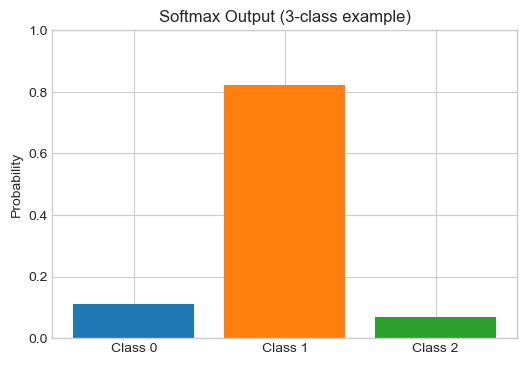

In [8]:
def softmax(z):
    """
    z: 1D array of length K (one score per class)
    Returns: probability vector of length K
    """
    z_shifted = z - np.max(z)  # stability trick
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

# Example: 3 classes — model prefers class 1
z_scores = np.array([1.0, 3.0, 0.5])
probs = softmax(z_scores)

print("Raw scores (logits):", z_scores)
print("Softmax probabilities:", np.round(probs, 4))
print("Sum of probabilities:", probs.sum())  # should be 1.0

plt.figure(figsize=(6, 4))
plt.bar(["Class 0", "Class 1", "Class 2"], probs, color=["C0", "C1", "C2"])
plt.ylabel("Probability")
plt.title("Softmax Output (3-class example)")
plt.ylim(0, 1)
plt.show()

## 4.7 Compare activations side by side

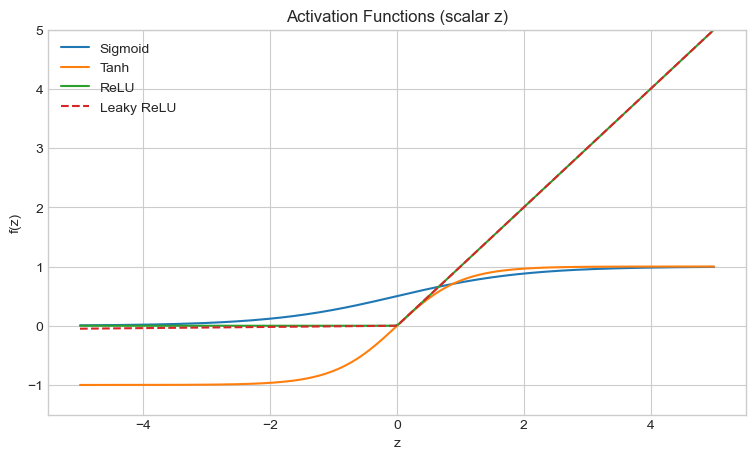

In [9]:
z_line = np.linspace(-5, 5, 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z_line, sigmoid(z_line), label="Sigmoid")
ax.plot(z_line, np.tanh(z_line), label="Tanh")
ax.plot(z_line, relu(z_line), label="ReLU")
ax.plot(z_line, leaky_relu(z_line), label="Leaky ReLU", linestyle="--")
ax.set_xlabel("z")
ax.set_ylabel("f(z)")
ax.set_title("Activation Functions (scalar z)")
ax.legend()
ax.set_ylim(-1.5, 5)
plt.show()

---
# Part 5: Forward Propagation Concept

**Forward propagation** means: data flows **input → output** through the network (no learning yet).

For **one neuron**, the pipeline is always three steps:

```
  Inputs x          Weights w, bias b          Activation f
      │                      │                        │
      └──────►  z = w·x + b  ──────►  a = f(z)  ──────► output a
```

1. **Linear step:** compute pre-activation \(z\).
2. **Activation step:** \(a = f(z)\).
3. Pass \(a\) to the next layer (or use as final prediction).

In a **deep** network, you repeat this for every neuron in each layer: layer 1 outputs become layer 2 inputs, and so on. Training uses **backpropagation** (later module) to adjust \(w\) and \(b\); forward prop only **uses** current weights.

Below we implement forward propagation explicitly so you can print each intermediate value.

In [10]:
def forward_one_neuron(x, w, b, activation_fn):
    """
    Forward propagation for a single neuron.
    
    Parameters
    ----------
    x : array-like, shape (n_features,)
    w : array-like, shape (n_features,)
    b : float, bias
    activation_fn : callable, maps z -> a
    
    Returns
    -------
    z : float, pre-activation
    a : float, post-activation output
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    
    z = np.dot(w, x) + b      # Step 1: linear
    a = activation_fn(z)      # Step 2: activation
    return z, a

# Example forward pass with ReLU
x = np.array([0.8, -0.3, 1.2])
w = np.array([1.5, 0.4, -0.7])
b = 0.1

z, a = forward_one_neuron(x, w, b, relu)

print("=== Forward propagation trace ===")
print("Inputs x:", x)
print("Weights w:", w)
print("Bias b:", b)
print("Dot product w·x:", np.dot(w, x))
print("Pre-activation z = w·x + b:", z)
print("Post-activation a = relu(z):", a)

=== Forward propagation trace ===
Inputs x: [ 0.8 -0.3  1.2]
Weights w: [ 1.5  0.4 -0.7]
Bias b: 0.1
Dot product w·x: 0.2400000000000001
Pre-activation z = w·x + b: 0.3400000000000001
Post-activation a = relu(z): 0.3400000000000001


---
# Part 6: Hands-on — Implement a Single Neuron with NumPy

We now wrap everything in a small **class** `SingleNeuron`:
- Stores `weights` and `bias`
- `forward(x)` runs full forward propagation
- Supports choosing activation by name

This is the same math as PyTorch/TensorFlow layers — just written clearly for learning.

In [11]:
ACTIVATIONS = {
    "sigmoid": sigmoid,
    "tanh": np.tanh,
    "relu": relu,
    "leaky_relu": leaky_relu,
}


class SingleNeuron:
    """
    A single artificial neuron: z = w·x + b, output = activation(z).
    """
    
    def __init__(self, n_inputs, activation="relu", leaky_alpha=0.01, seed=42):
        rng = np.random.default_rng(seed)
        # Small random weights are a common initialization
        self.weights = rng.normal(loc=0.0, scale=0.1, size=n_inputs)
        self.bias = 0.0
        self.leaky_alpha = leaky_alpha
        
        if activation not in ACTIVATIONS:
            raise ValueError(f"activation must be one of {list(ACTIVATIONS)}")
        self.activation_name = activation
        self._activation = ACTIVATIONS[activation]
    
    def forward(self, x):
        """Forward propagation. Returns (z, output)."""
        x = np.asarray(x, dtype=float)
        if x.shape != self.weights.shape:
            raise ValueError(
                f"Expected input shape {self.weights.shape}, got {x.shape}"
            )
        z = self.weights @ x + self.bias
        if self.activation_name == "leaky_relu":
            out = leaky_relu(z, self.leaky_alpha)
        else:
            out = self._activation(z)
        return z, out
    
    def __repr__(self):
        return (
            f"SingleNeuron(n_inputs={len(self.weights)}, "
            f"activation={self.activation_name!r})"
        )

In [12]:
# --- Demo: one neuron, different activations ---

sample_input = np.array([1.0, -0.5, 2.0])
print("Sample input:", sample_input)
print()

for act in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    neuron = SingleNeuron(n_inputs=3, activation=act, seed=7)
    # Set known weights for reproducible demo (normally learned by training)
    neuron.weights = np.array([0.2, -0.4, 0.6])
    neuron.bias = 0.05
    z, out = neuron.forward(sample_input)
    print(f"{act:12} | z = {z:7.4f} | output = {out:.4f}")

Sample input: [ 1.  -0.5  2. ]

sigmoid      | z =  1.6500 | output = 0.8389
tanh         | z =  1.6500 | output = 0.9289
relu         | z =  1.6500 | output = 1.6500
leaky_relu   | z =  1.6500 | output = 1.6500


## 6.1 Mini example: binary decision intuition (sigmoid neuron)

Imagine predicting **"will it rain?"** from two features:
- \(x_1\): humidity (0 to 1)
- \(x_2\): cloud cover (0 to 1)

We **hand-set** weights (in real life, training finds them). High humidity and clouds should push output toward 1.

In [13]:
rain_neuron = SingleNeuron(n_inputs=2, activation="sigmoid")
rain_neuron.weights = np.array([3.0, 2.5])   # both features increase rain score
rain_neuron.bias = -2.0                       # need strong evidence to say "rain"

scenarios = {
    "Dry and clear": np.array([0.1, 0.1]),
    "Humid, few clouds": np.array([0.9, 0.2]),
    "Humid and cloudy": np.array([0.85, 0.9]),
}

print(f"{'Scenario':22} | P(rain) approx.")
print("-" * 40)
for name, x in scenarios.items():
    z, prob = rain_neuron.forward(x)
    print(f"{name:22} | {prob:.3f}  (z={z:.2f})")

Scenario               | P(rain) approx.
----------------------------------------
Dry and clear          | 0.190  (z=-1.45)
Humid, few clouds      | 0.769  (z=1.20)
Humid and cloudy       | 0.943  (z=2.80)


## 6.2 Softmax layer = one "neuron" per class (vector forward pass)

For 3 classes we often have **3 weights vectors** (or one weight matrix). Here we compute 3 logits and apply softmax once — that is forward propagation for the **output layer**.

In [14]:
def forward_softmax_layer(x, W, b):
    """
    x: shape (n_features,)
    W: shape (n_classes, n_features) — one weight row per class
    b: shape (n_classes,)
    """
    logits = W @ x + b
    probs = softmax(logits)
    return logits, probs

# Toy: classify fruit from [weight_grams, redness]
x_fruit = np.array([150.0, 0.9])  # heavy and very red
W = np.array([
    [0.01, 0.1],   # class 0: apple-like
    [-0.02, 0.15], # class 1: cherry-like
    [0.005, -0.2], # class 2: banana-like (low redness)
])
b_vec = np.array([-1.0, -1.5, 0.0])

logits, probs = forward_softmax_layer(x_fruit, W, b_vec)
classes = ["Apple", "Cherry", "Banana"]

print("Logits:", np.round(logits, 3))
for c, p in zip(classes, probs):
    print(f"  P({c}) = {p:.3f}")

Logits: [ 0.59  -4.365  0.57 ]
  P(Apple) = 0.503
  P(Cherry) = 0.004
  P(Banana) = 0.493


---
# Part 7: Practice Exercises (Try Yourself)

1. **Weighted sum:** Set `x = [1, 2, 3]` and `w = [0, 1, 0]`. What is `z`? Which input mattered?
2. **Bias:** With the same `x` and `w`, find `b` so that `z = 0` before activation.
3. **ReLU:** For `z = -2, 0, 4`, compute ReLU by hand and verify with `relu(z)`.
4. **Softmax:** logits `[0, 0, 0]` should give equal probabilities. Verify in code.
5. **Build:** Create `SingleNeuron(4, activation='tanh')` and call `forward` on any length-4 vector.

*Solutions are in the next cell — try first!*

In [15]:
# --- Exercise solutions (run after you try) ---

x_ex = np.array([1, 2, 3])
w_ex = np.array([0, 1, 0])
z_ex = w_ex @ x_ex
print("1) z =", z_ex, "— only x[1]=2 matters")

b_ex = -z_ex
print("2) b =", b_ex, "makes z=0")

print("3) relu([-2,0,4]) =", relu(np.array([-2, 0, 4])))

print("4) softmax([0,0,0]) =", softmax(np.array([0.0, 0.0, 0.0])))

n = SingleNeuron(4, activation="tanh", seed=0)
print("5)", n.forward(np.array([1, -1, 0.5, 2]))[1])

1) z = 2 — only x[1]=2 matters
2) b = -2 makes z=0
3) relu([-2,0,4]) = [0 0 4]
4) softmax([0,0,0]) = [0.33333333 0.33333333 0.33333333]
5) 0.07862206200637642


---
# Summary Cheat Sheet

| Concept | Formula / Code |
|---------|----------------|
| Weighted sum | `z = np.dot(w, x)` or `w @ x` |
| With bias | `z = w @ x + b` |
| Sigmoid | `1 / (1 + np.exp(-z))` |
| Tanh | `np.tanh(z)` |
| ReLU | `np.maximum(0, z)` |
| Leaky ReLU | `np.where(z > 0, z, alpha * z)` |
| Softmax | `exp(z - max(z)) / sum(...)` |
| Forward pass | linear → activation |

**Next steps (future modules):** loss functions, backpropagation, training loops with many neurons and layers.

---
*End of Module 1 lab notebook.*